# Explore here

## Decision Tree Project

**Problem Statement:** Predict whether a patient has diabetes based on diagnostic measures.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
from pickle import dump
import warnings

warnings.filterwarnings('ignore')

## 1. Load the Dataset

In [ ]:
URL = "https://breathecode.herokuapp.com/asset/internal-link?id=421&path=diabetes.csv"
df = pd.read_csv(URL)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. High-Level View of the Data

In [ ]:
print("Shape:")
print(df.shape)

print("\ndtypes & non-null counts:")
df.info()

Shape:
(768, 9)

dtypes & non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Identify numerical variables and separate target
target = "Outcome"
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numerical_cols if c != target]

## 3. Data Cleaning

In [ ]:
# Null values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Finding the Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [ ]:
# Biologically impossible zeros
# Glucose, BloodPressure, SkinThickness, Insulin, BMI cannot be 0 (because the patient would be dead if they were)
imp_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("Zero counts:")

for col in imp_zero_cols:
    n = (df[col] == 0).sum()
    pct = n / len(df) * 100
    print(f"  {col:}: {n}  ({pct:.1f} %)")

Zero counts:
  Glucose: 5  (0.7 %)
  BloodPressure: 35  (4.6 %)
  SkinThickness: 227  (29.6 %)
  Insulin: 374  (48.7 %)
  BMI: 11  (1.4 %)


Here we can notice something: The Insulin and SkinThickness columns have 48.7% and 29.6% impossible zeroes, respectively. Meaning, if we replaced those values with NaN and then did the median imputation process, we would basically have one column that was about half "garbage" and another column that was about 30% "garbage". It would be better to just get rid of the columns.

In [ ]:
df = df.drop(["Insulin", "SkinThickness"], axis=1)

imp_zero_cols = imp_zero_cols[:2] + imp_zero_cols[4:]

feature_cols.remove("SkinThickness")
feature_cols.remove("Insulin")

feature_cols

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [ ]:
# Replace zeros with NaN, then impute with median
df[imp_zero_cols] = df[imp_zero_cols].replace(0, np.nan)

for col in imp_zero_cols:
    df[col] = df.groupby(target)[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## 4. Descriptive Statistics

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,67.100000,2.420000,81.000000,1.000000


## 5. Univariate Analysis

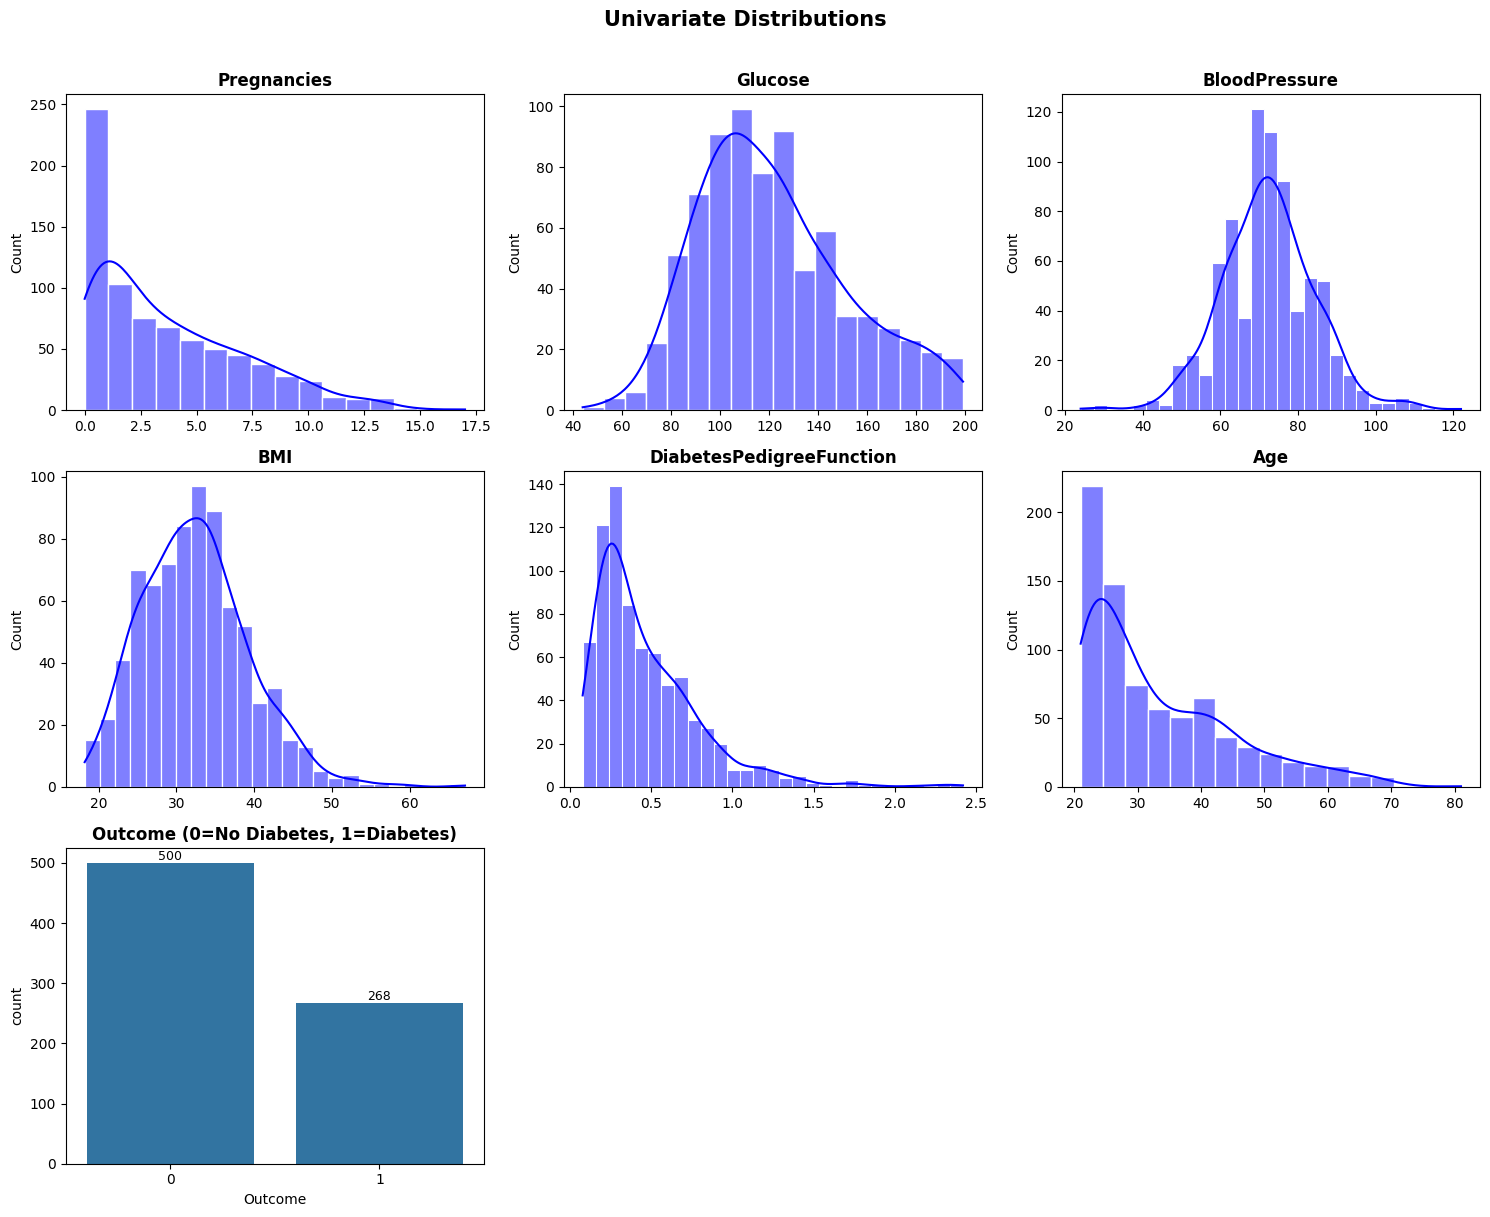

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color="blue", edgecolor="white")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("")

# Last subplot: target counts
ax = axes[len(feature_cols)]
sns.countplot(x=target, data=df, ax=ax)
ax.set_title("Outcome (0=No Diabetes, 1=Diabetes)", fontsize=12, fontweight="bold")
ax.bar_label(ax.containers[0], fontsize=9)

for j in range(len(feature_cols) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Univariate Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6. Verbal Analysis - Univariate Graphs

**Pregnancies** Right-skewed; most patients have 0-3 pregnancies.

**Glucose** Higher values are associated with diabetes.

**BloodPressure** Near-normal distribution centred around 70 mm Hg. Some extreme low/high values remain.

**BMI** Roughly normal, centred around 32. Minimal skew after imputation.

**DiabetesPedigreeFunction** Strongly right-skewed with a long tail; most values are < 1.0.

**Age** Right-skewed; most patients are in their 20s-30s. The tail extends to 81.

**Outcome** Imbalanced: around 65% negative (0) vs 35% positive (1). This should be considered during modelling.

**Overall takeaways:**
- Several features (DiabetesPedigreeFunction, Pregnancies, Age) are skewed and contain outliers that need treatment.
- The target is moderately imbalanced; techniques like stratified splitting or class-weight adjustment may be helpful later.

## 7. Multivariate Analysis

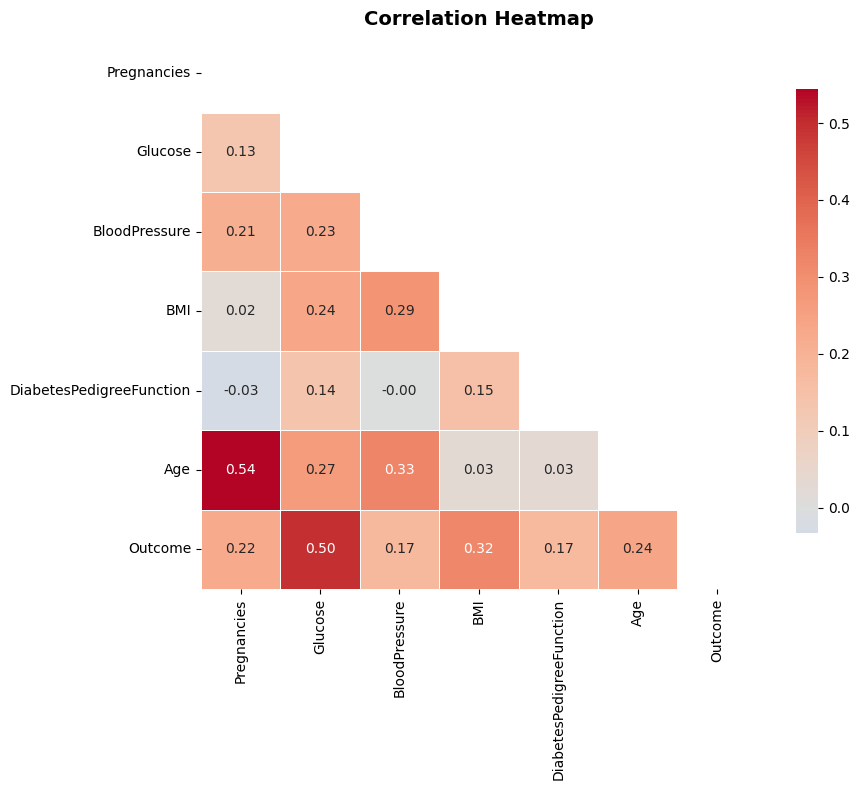

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

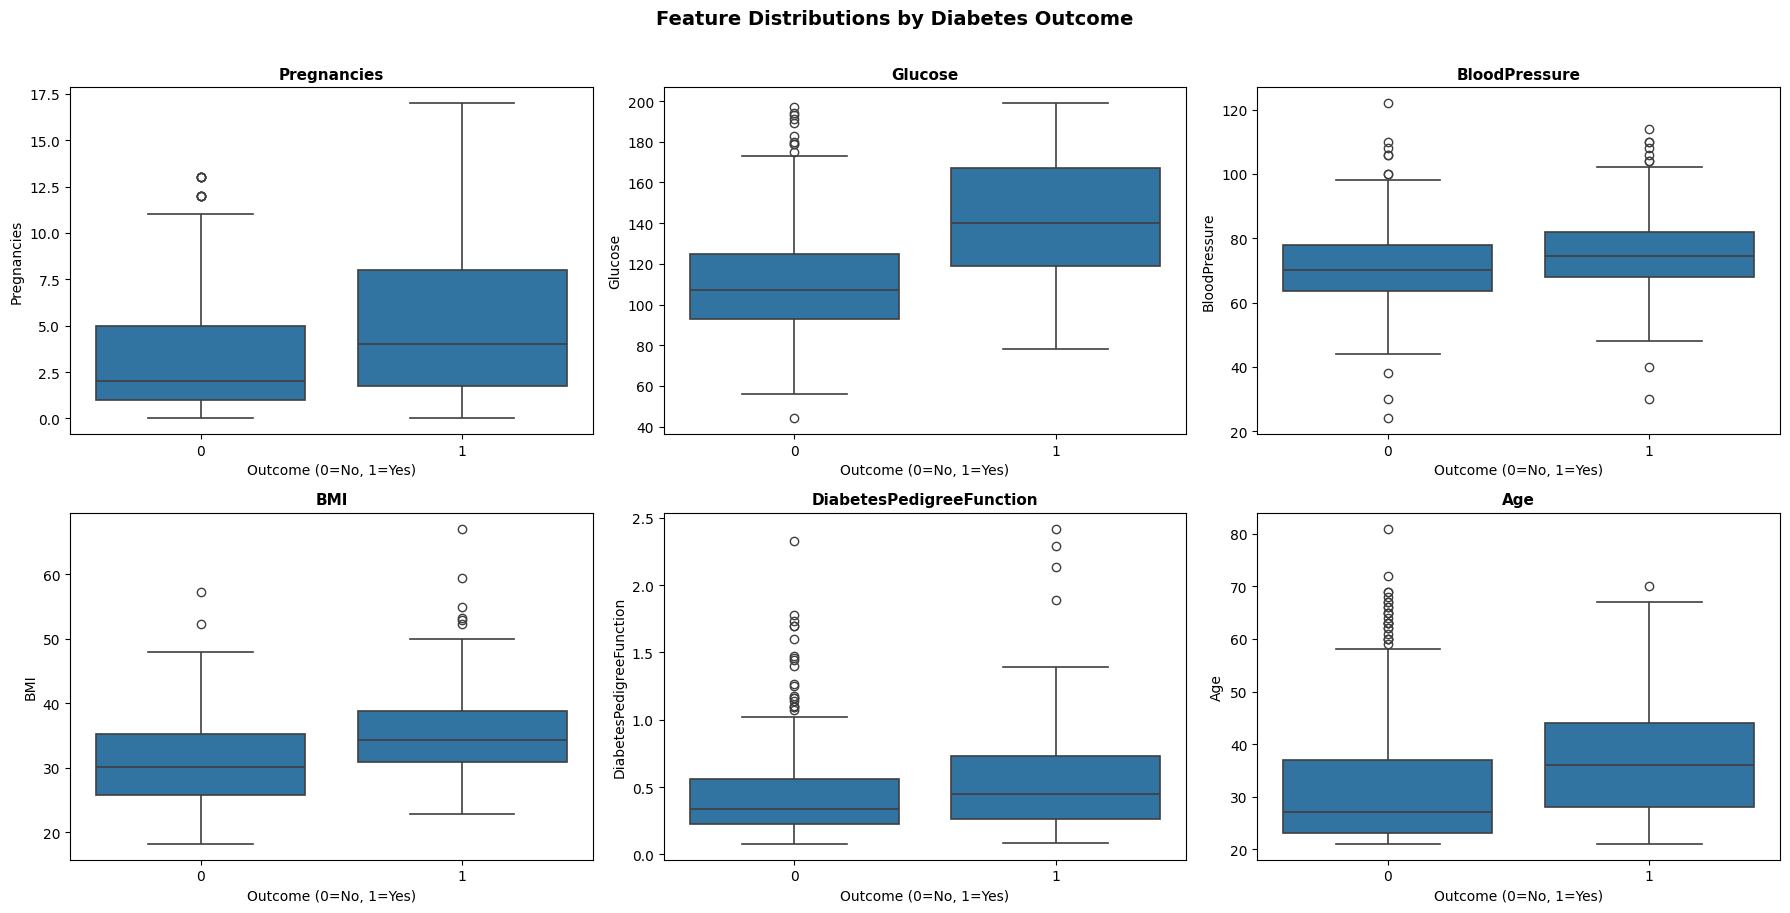

In [ ]:
# --- Boxplots by Outcome ---
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
palette = {0: "#4C9BE8", 1: "#E8694C"}

for i, col in enumerate(feature_cols):
    sns.boxplot(x=target, y=col, data=df, ax=axes[i], linewidth=1.2)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Outcome (0=No, 1=Yes)")

plt.suptitle("Feature Distributions by Diabetes Outcome", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

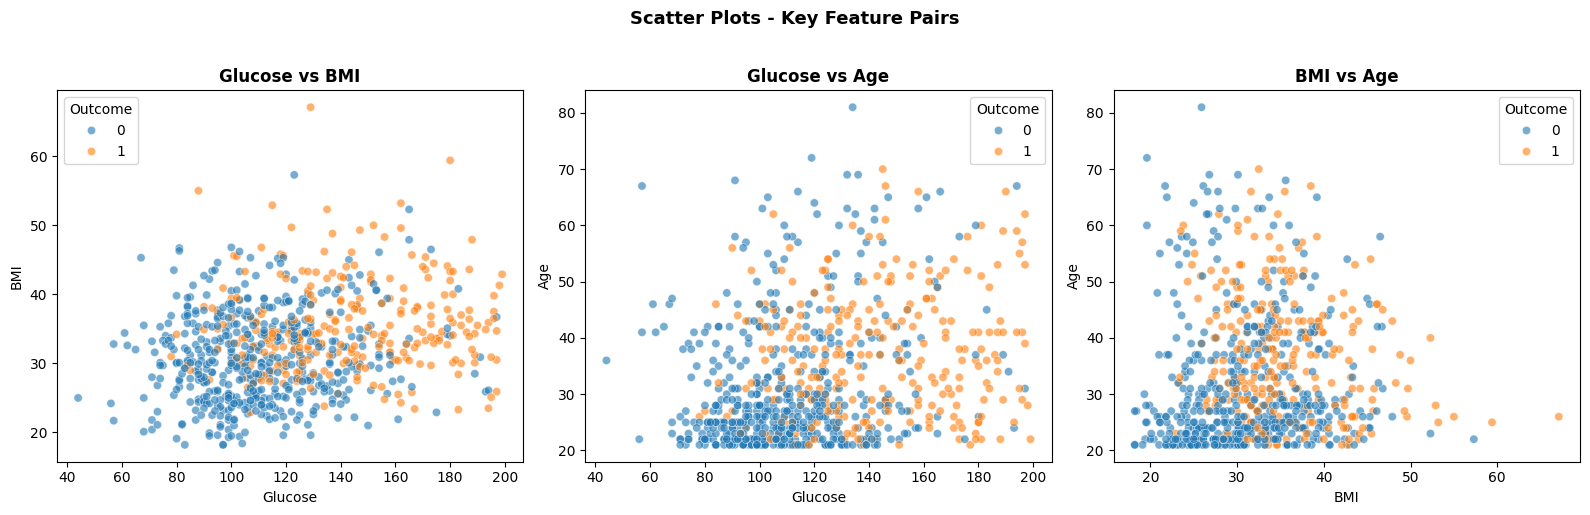

In [ ]:
# Scatter plots: key feature pairs
pairs = [("Glucose", "BMI"), ("Glucose", "Age"), ("BMI", "Age")]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=df, x=x, y=y, hue=target,
                    alpha=0.6, ax=ax)
    ax.set_title(f"{x} vs {y}", fontweight="bold")

plt.suptitle("Scatter Plots - Key Feature Pairs", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Verbal Analysis - Multivariate Graphs

### Correlation Heatmap
- Glucose has the strongest correlation with Outcome (about 0.47), confirming it as the most predictive single feature.
- BMI and Age show moderate positive correlations with the outcome (about 0.29 and 0.24 respectively).

### Boxplots by Outcome
- Glucose: Diabetic patients show a markedly higher median glucose level - the clearest separator.
- BMI: Diabetic patients are consistently heavier; distributions overlap but medians differ by about 5 units.
- Age: Diabetic patients tend to be older; the diabetic group also shows more variability.

### Scatter Plots
- Glucose vs BMI: Diabetic cases cluster toward the high-glucose, high-BMI corner - a clear separation.
- Glucose vs Age: Older plus high-glucose patients are predominantly diabetic.
- BMI vs Age: Overlap is larger; BMI alone without glucose is a weaker separator.

## 9. Feature Engineering

In [ ]:
df_eng = df.copy()

# Outlier handling with IQR capping
skewed_cols = ["Pregnancies", "DiabetesPedigreeFunction", "Age"]

for col in skewed_cols:
    Q1, Q3 = df_eng[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_clipped = ((df_eng[col] < lower) | (df_eng[col] > upper)).sum()
    df_eng[col] = df_eng[col].clip(lower, upper)
    print(f"  {col:30s}: {n_clipped} outliers capped  [{lower:.2f} - {upper:.2f}]")

  Pregnancies                   : 4 outliers capped  [-6.50 - 13.50]
  DiabetesPedigreeFunction      : 29 outliers capped  [-0.33 - 1.20]
  Age                           : 9 outliers capped  [-1.50 - 66.50]


In [ ]:
# No encoding needed - all features are numeric
print(f"Engineered dataframe shape: {df_eng.shape}")

Engineered dataframe shape: (768, 7)


In [ ]:
# Scaling
X = df_eng[feature_cols].copy()
y = df_eng[target].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X),
                        columns=feature_cols,
                        index=X.index)

print("Features after scaling:")
X_scaled.describe().loc[["mean", "std"]].round(4)

Features after scaling:


,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
mean,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000
std,1.0007,1.0007,1.0007,1.0007,1.0007,1.0007


## 10. Feature Selection - SelectKBest (f_classif)

In [ ]:
selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X_scaled, y)

feat_scores = pd.DataFrame({
    "Feature": feature_cols,
    "F-Score": selector.scores_,
    "p-value": selector.pvalues_
}).sort_values("F-Score", ascending=False).reset_index(drop=True)

print(feat_scores.to_string(index=False))

                 Feature    F-Score      p-value
                 Glucose 249.923949 6.226933e-49
                     BMI  84.722280 3.209941e-19
                     Age  47.944757 9.284605e-12
             Pregnancies  39.106100 6.666771e-10
DiabetesPedigreeFunction  27.135876 2.439853e-07
           BloodPressure  24.048567 1.147458e-06


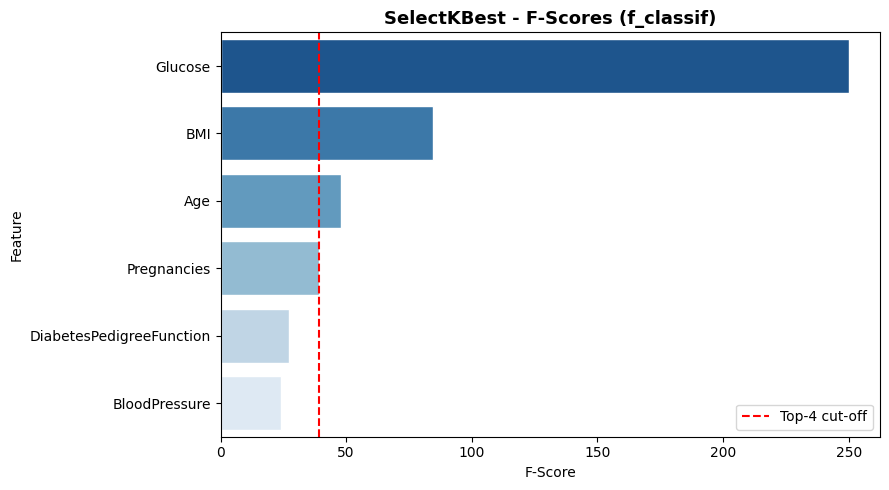

In [ ]:
# Visualise
plt.figure(figsize=(9, 5))
sns.barplot(data=feat_scores, x="F-Score", y="Feature",
            palette="Blues_r", edgecolor="white")
plt.axvline(feat_scores["F-Score"].iloc[3], color="red",
            linestyle="--", label="Top-4 cut-off")
plt.title("SelectKBest - F-Scores (f_classif)", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Select Top-4 features
K = 4
top_k = feat_scores["Feature"].head(K).tolist()
print(f"Selected top-{K} features: {top_k}")

X_selected = X_scaled[top_k]

Selected top-4 features: ['Glucose', 'BMI', 'Age', 'Pregnancies']


## 11. Train / Test Split and Save

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size : {X_train.shape}  |  Test size : {X_test.shape}")
print(f"Train outcome balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest  outcome balance:\n{y_test.value_counts(normalize=True).round(3)}")

Train size : (614, 4)  |  Test size : (154, 4)
Train outcome balance:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Test  outcome balance:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


In [ ]:
# Save the final datasets to CSV files
X_train.assign(Outcome=y_train.values).to_csv("train.csv", index=False)
X_test.assign(Outcome=y_test.values).to_csv("test.csv", index=False)

## Random Forest Model (same EDA and dataset from Decision Tree project - I just copy/Pasted)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 60, random_state = 42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",60
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7597402597402597

In [ ]:
from pickle import dump

dump(model, open("../models/ranfor_classifier_nestimators-60_42.sav", "wb"))